# Control policy evaluation template

Fill in `control_policy` below, then run all cells in order.

The simulation runs `N_R * N_THETA` trials across a polar grid of targets, records distance-to-target, joint-angle errors, and control effort, then summarises the results in a metrics table and a single figure.

In [2]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../week_3')   # BMI_and_Hand.py + weights .npz live here in this repo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.interpolate import griddata
from tqdm.auto import tqdm
import importlib, hand_control as hc
importlib.reload(hc)

from GG4 import Brain
from BMI_and_Hand import BMI_and_Hand

In [3]:
# Evaluation grid
T            = 1000    # steps per trial
DEMO_SEED    = 0       # random seed for Brain
N_SNAPSHOTS  = 6       # arm snapshots in trajectory plot
TARGET_R_MIN = 20.0    # cm
TARGET_R_MAX = 55.0    # cm
N_R          = 3       # radial grid points
N_THETA      = 10       # angular grid points

# Geometry
ARM_LINK     = 30.0    # cm, both links equal
MAX_DELTA    = 0.25    # rad, IK branch-change guard

# Metrics
DIST_THRESH  = 10.0    # cm, threshold for time-to-target metric
DEMO_IDX     = 0       # which trial to show in the trajectory panel

## Control policy

Replace the body of `control_policy` with your implementation.

In [4]:
# ============================ V1 control policy ============================ #
# Select-tone IK joint-servo with hand-position feedback (full design in
# hand_control.HandController). In one line: the muscle head selects a muscle by
# the FREQUENCY of the x1 latent and powers it from the x2 latent's natural DC
# offset, so each joint error -> a sinusoidal "select tone" at that muscle's
# frequency, amplitude proportional to the error. Shoulder = muscles 0/1, elbow
# = muscles 2/3, giving two independent servos in IK joint-space; inside the
# deadzone the tones drop and joint stiction holds the pose.
#
# The select frequencies and (frequency -> joint, direction) map are
# brain-INVARIANT (fixed by the ANN + arm, not the per-trial brain). They were
# discovered offline once by hc.calibrate_frequencies(...) and are fixed here:
_PRIMITIVES = [
    {"f": 0.073, "joint": 0, "sign": +1},   # shoulder +
    {"f": 0.133, "joint": 0, "sign": -1},   # shoulder -
    {"f": 0.207, "joint": 1, "sign": +1},   # elbow +
    {"f": 0.312, "joint": 1, "sign": -1},   # elbow -
]
# V1 = "hand": joint estimate comes from the measured current_pos (IK).
_policy = hc.HandController(_PRIMITIVES, mode="hand")


def control_policy(observations, target, current_pos):
    '''V1 controller: select-tone joint-servo with hand-position feedback.

    observations : list of past brain measurements (empty on the first step)
    target       : (x, y) target hand position, cm
    current_pos  : (x, y) current hand position, cm  -> the V1 feedback signal
    returns      : u (2,) brain stimulation for this step, in [0, 1]
    '''
    if len(observations) == 0:        # a fresh observations list = new trial
        _policy.reset()               # clear stateful servo (phase, target, IK history)
    return _policy(observations, target, current_pos)

In [5]:
def _ik(x, y, prev_sh=0.0, prev_el=0.0):
    r2 = x**2 + y**2
    cos_el = np.clip((r2 - 2 * ARM_LINK**2) / (2 * ARM_LINK**2), -1.0, 1.0)
    el_pos = float(np.arccos(cos_el))
    el_neg = -el_pos

    def _sh(el):
        s = np.arctan2(y, x) - np.arctan2(
            ARM_LINK * np.sin(el), ARM_LINK + ARM_LINK * np.cos(el)
        )
        return float(np.arctan2(np.sin(s), np.cos(s)))

    def _wrap_dist(a, b):
        d = a - b
        return float(np.arctan2(np.sin(d), np.cos(d)))

    sh_pos, sh_neg = _sh(el_pos), _sh(el_neg)
    err_pos = _wrap_dist(sh_pos, prev_sh)**2 + _wrap_dist(el_pos, prev_el)**2
    err_neg = _wrap_dist(sh_neg, prev_sh)**2 + _wrap_dist(el_neg, prev_el)**2
    return (sh_pos, el_pos) if err_pos <= err_neg else (sh_neg, el_neg)

In [6]:
r_grid     = np.linspace(TARGET_R_MIN, TARGET_R_MAX, N_R)
theta_grid = np.linspace(-np.pi, np.pi, N_THETA, endpoint=False)
R, TH      = np.meshgrid(r_grid, theta_grid, indexing='ij')

targets = [
    (float(R[ri, ti] * np.cos(TH[ri, ti])), float(R[ri, ti] * np.sin(TH[ri, ti])))
    for ri in range(N_R)
    for ti in range(N_THETA)
]
N_TRIALS = N_R * N_THETA

all_hand        = [None] * N_TRIALS
all_sh          = [None] * N_TRIALS
all_el          = [None] * N_TRIALS
all_dist        = np.zeros((N_TRIALS, T))
all_sh_err      = np.zeros((N_TRIALS, T))
all_el_err      = np.zeros((N_TRIALS, T))
all_effort      = np.zeros(N_TRIALS)
final_dist_grid = np.zeros((N_R, N_THETA))

with tqdm(total=N_TRIALS, desc='Evaluating', unit='trial') as pbar:
    for i, tgt in enumerate(targets):
        bmi          = BMI_and_Hand(Brain(random_seed=DEMO_SEED))
        target_xy    = np.array(tgt)
        observations = []
        hand_traj    = np.zeros((T, 2))
        sh_traj      = np.zeros(T)
        el_traj      = np.zeros(T)
        u_list       = []
        prev_sh = prev_el = 0.0

        for step in range(T):
            current_pos = bmi.hand_pos
            y = np.array(bmi._brain.measure())
            u = np.asarray(control_policy(observations, tgt, current_pos), dtype=float)
            observations.append(y)
            bmi.next_state(u.tolist())
            x_h, y_h = bmi.hand_pos
            hand_traj[step] = [x_h, y_h]
            sh, el = _ik(x_h, y_h, prev_sh, prev_el)
            sh_traj[step] = sh if abs(sh - prev_sh) <= MAX_DELTA else prev_sh
            el_traj[step] = el if abs(el - prev_el) <= MAX_DELTA else prev_el
            prev_sh, prev_el = sh_traj[step], el_traj[step]
            u_list.append(u)

        dist           = np.linalg.norm(hand_traj - target_xy, axis=1)
        tgt_sh, tgt_el = _ik(*tgt)
        ri, ti         = divmod(i, N_THETA)

        all_hand[i]    = hand_traj
        all_sh[i]      = sh_traj
        all_el[i]      = el_traj
        all_dist[i]    = dist
        all_sh_err[i]  = np.abs(np.arctan2(
            np.sin(sh_traj - tgt_sh), np.cos(sh_traj - tgt_sh)
        ))
        all_el_err[i]  = np.abs(np.arctan2(
            np.sin(el_traj - tgt_el), np.cos(el_traj - tgt_el)
        ))
        all_effort[i]  = float(np.sum(np.stack(u_list) ** 2))
        final_dist_grid[ri, ti] = dist[-1]

        pbar.set_postfix(
            target=f'({tgt[0]:.0f},{tgt[1]:.0f})',
            final_err=f'{dist[-1]:.1f} cm',
        )
        pbar.update(1)

Evaluating:   0%|          | 0/30 [00:00<?, ?trial/s]

In [7]:
ss_start = (2 * T) // 3

def _time_to_thresh(dist_trial):
    hits = np.where(dist_trial < DIST_THRESH)[0]
    return int(hits[0]) if len(hits) > 0 else np.nan

time_to_thresh = np.array(
    [_time_to_thresh(all_dist[i]) for i in range(N_TRIALS)], dtype=float
)
ss_dist      = all_dist[:, ss_start:].mean(axis=1)
final_dist   = all_dist[:, -1]
final_sh_err = np.degrees(all_sh_err[:, -1])
final_el_err = np.degrees(all_el_err[:, -1])
n_reached    = int(np.sum(~np.isnan(time_to_thresh)))

records = [
    ('Time to threshold',
     'steps',
     np.nanmean(time_to_thresh),
     np.nanstd(time_to_thresh),
     f'< {DIST_THRESH} cm; {n_reached}/{N_TRIALS} trials reached'),
    ('Steady-state distance',
     'cm',
     ss_dist.mean(),
     ss_dist.std(),
     f'mean over steps {ss_start} to {T}'),
    ('Final distance to target',
     'cm',
     final_dist.mean(),
     final_dist.std(),
     'at step T - 1'),
    ('Final shoulder angle error',
     'deg',
     final_sh_err.mean(),
     final_sh_err.std(),
     'at step T - 1'),
    ('Final elbow angle error',
     'deg',
     final_el_err.mean(),
     final_el_err.std(),
     'at step T - 1'),
    ('Control effort',
     'a.u.',
     all_effort.mean(),
     all_effort.std(),
     'sum of squared inputs over trial'),
]

df_metrics = pd.DataFrame(
    records,
    columns=['Metric', 'Unit', 'Mean', 'Std', 'Notes'],
)
df_metrics['Mean'] = df_metrics['Mean'].map('{:.2f}'.format)
df_metrics['Std']  = df_metrics['Std'].map('{:.2f}'.format)
df_metrics

,Metric,Unit,Mean,Std,Notes
0,Time to threshold,steps,401.06,211.21,< 10.0 cm; 17/30 trials reached
1,Steady-state distance,cm,32.66,31.40,mean over steps 666 to 1000
2,Final distance to target,cm,32.30,33.36,at step T - 1
3,Final shoulder angle error,deg,19.31,23.07,at step T - 1
4,Final elbow angle error,deg,53.14,62.97,at step T - 1
5,Control effort,a.u.,617.34,23.37,sum of squared inputs over trial


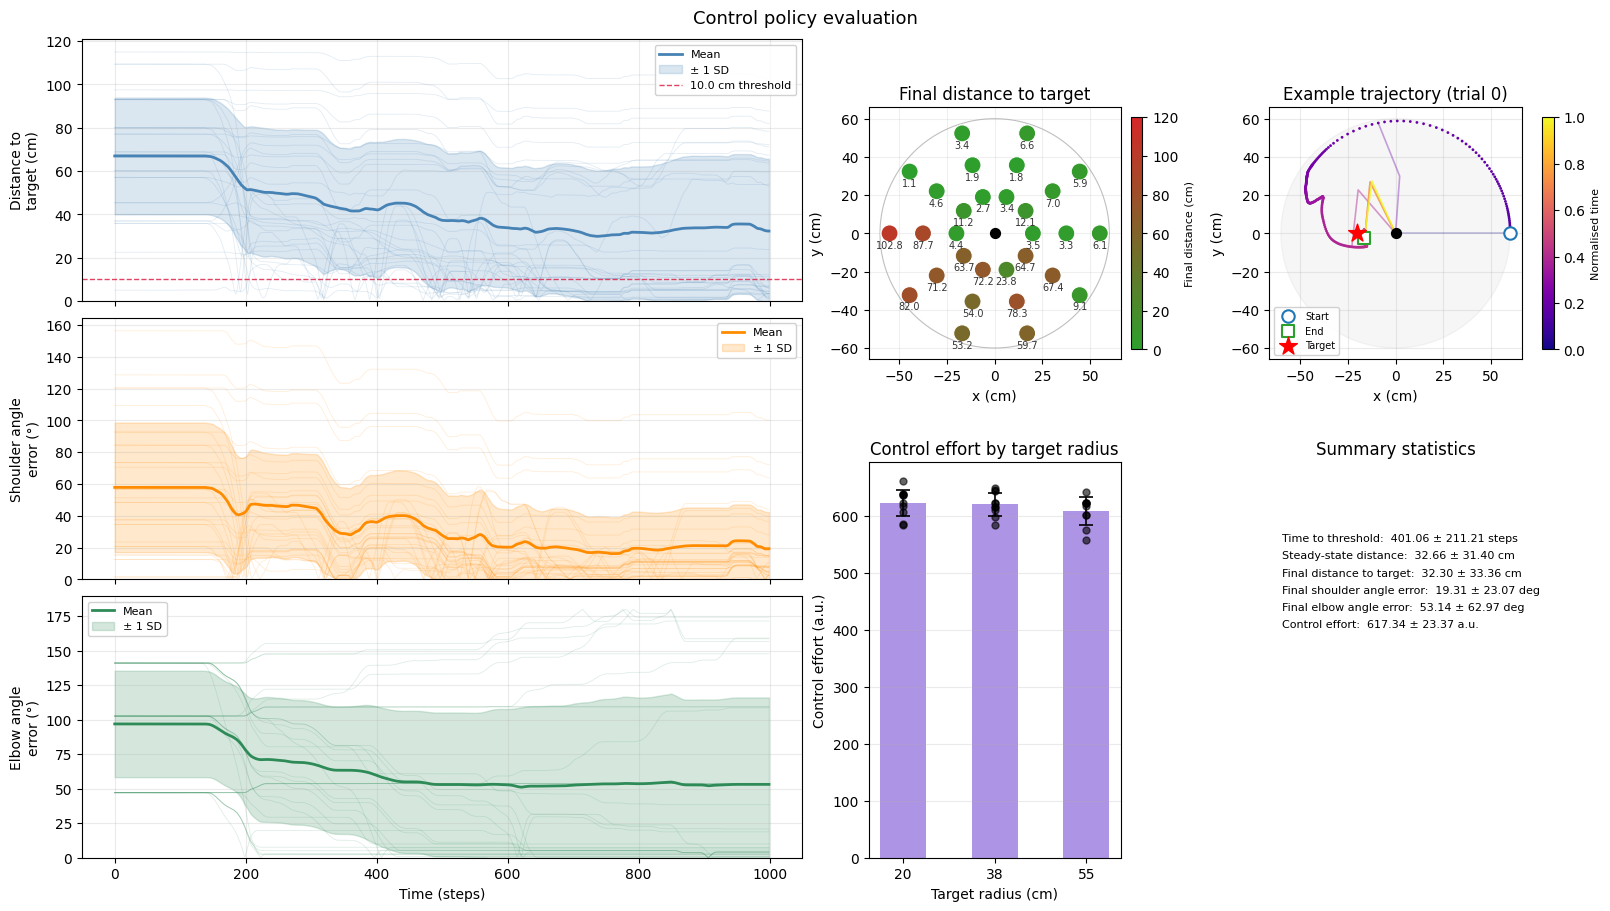

In [8]:
t_axis    = np.arange(T)
dist_mean = all_dist.mean(axis=0)
dist_std  = all_dist.std(axis=0)
sh_mean   = np.degrees(all_sh_err.mean(axis=0))
sh_std    = np.degrees(all_sh_err.std(axis=0))
el_mean   = np.degrees(all_el_err.mean(axis=0))
el_std    = np.degrees(all_el_err.std(axis=0))
theta_ws  = np.linspace(0, 2 * np.pi, 300)
span      = 2 * ARM_LINK

fig = plt.figure(figsize=(16, 9), constrained_layout=True)
gs       = fig.add_gridspec(1, 2)
gs_left  = gs[0].subgridspec(3, 1)
gs_right = gs[1].subgridspec(2, 2)

ax_dist = fig.add_subplot(gs_left[0])
ax_sh   = fig.add_subplot(gs_left[1], sharex=ax_dist)
ax_el   = fig.add_subplot(gs_left[2], sharex=ax_dist)
ax_hm   = fig.add_subplot(gs_right[0, 0])
ax_traj = fig.add_subplot(gs_right[0, 1])
ax_eff  = fig.add_subplot(gs_right[1, 0])
ax_stat = fig.add_subplot(gs_right[1, 1])

# (a) Distance to target
for d in all_dist:
    ax_dist.plot(t_axis, d, color='steelblue', alpha=0.15, lw=0.6)
ax_dist.plot(t_axis, dist_mean, color='steelblue', lw=2.0, label='Mean')
ax_dist.fill_between(t_axis,
                     dist_mean - dist_std,
                     dist_mean + dist_std,
                     color='steelblue', alpha=0.20, label='± 1 SD')
ax_dist.axhline(DIST_THRESH, color='crimson', ls='--', lw=1.0, alpha=0.8,
                label=f'{DIST_THRESH} cm threshold')
ax_dist.set_ylabel('Distance to\ntarget (cm)')
ax_dist.set_ylim(bottom=0)
ax_dist.legend(fontsize=8, framealpha=0.9)
ax_dist.grid(True, alpha=0.25)
plt.setp(ax_dist.get_xticklabels(), visible=False)

# (b) Shoulder angle error
for d in np.degrees(all_sh_err):
    ax_sh.plot(t_axis, d, color='darkorange', alpha=0.15, lw=0.6)
ax_sh.plot(t_axis, sh_mean, color='darkorange', lw=2.0, label='Mean')
ax_sh.fill_between(t_axis,
                   sh_mean - sh_std,
                   sh_mean + sh_std,
                   color='darkorange', alpha=0.20, label='± 1 SD')
ax_sh.set_ylabel('Shoulder angle\nerror (°)')
ax_sh.set_ylim(bottom=0)
ax_sh.legend(fontsize=8, framealpha=0.9)
ax_sh.grid(True, alpha=0.25)
plt.setp(ax_sh.get_xticklabels(), visible=False)

# (c) Elbow angle error
for d in np.degrees(all_el_err):
    ax_el.plot(t_axis, d, color='seagreen', alpha=0.15, lw=0.6)
ax_el.plot(t_axis, el_mean, color='seagreen', lw=2.0, label='Mean')
ax_el.fill_between(t_axis,
                   el_mean - el_std,
                   el_mean + el_std,
                   color='seagreen', alpha=0.20, label='± 1 SD')
ax_el.set_xlabel('Time (steps)')
ax_el.set_ylabel('Elbow angle\nerror (°)')
ax_el.set_ylim(bottom=0)
ax_el.legend(fontsize=8, framealpha=0.9)
ax_el.grid(True, alpha=0.25)

# (d) Final distance to target (scatter only, no interpolation)
cmap_gr = LinearSegmentedColormap.from_list('gr', ['#2ca02c', '#d62728'])
norm_hm = Normalize(vmin=0, vmax=120)
tgt_x   = np.array([t[0] for t in targets])
tgt_y   = np.array([t[1] for t in targets])
tgt_d   = final_dist_grid.ravel()
ax_hm.plot(span * np.cos(theta_ws), span * np.sin(theta_ws),
           color='grey', lw=0.8, alpha=0.5, zorder=1)
sc_hm = ax_hm.scatter(tgt_x, tgt_y, c=tgt_d, cmap=cmap_gr, norm=norm_hm,
                      s=150, zorder=3, linewidths=0.8, edgecolors='white')
for xi_, yi_, di in zip(tgt_x, tgt_y, tgt_d):
    ax_hm.text(xi_, yi_ - 3.5, f'{di:.1f}', ha='center', va='top',
               fontsize=7, color='0.2', zorder=4)
cbar = fig.colorbar(sc_hm, ax=ax_hm, fraction=0.046, pad=0.04)
cbar.set_label('Final distance (cm)', fontsize=8)
ax_hm.scatter(0, 0, s=50, color='k', zorder=6)
ax_hm.set_aspect('equal')
ax_hm.set_xlabel('x (cm)')
ax_hm.set_ylabel('y (cm)')
ax_hm.set_title('Final distance to target')
ax_hm.grid(True, alpha=0.2)

# (e) Example trajectory
cmap_traj = plt.get_cmap('plasma')
norm_c    = Normalize(vmin=0, vmax=1)
demo_hand   = all_hand[DEMO_IDX]
demo_sh     = all_sh[DEMO_IDX]
demo_el     = all_el[DEMO_IDX]
demo_target = targets[DEMO_IDX]
n_steps     = demo_hand.shape[0]
t_norm      = np.linspace(0.0, 1.0, n_steps)
ax_traj.fill(
    span * np.cos(theta_ws),
    span * np.sin(theta_ws),
    color='grey', alpha=0.07, zorder=0,
)
sc = ax_traj.scatter(
    demo_hand[:, 0], demo_hand[:, 1],
    c=t_norm, cmap='plasma', s=4, zorder=3, linewidths=0,
)
cbar2 = fig.colorbar(sc, ax=ax_traj, fraction=0.046, pad=0.04)
cbar2.set_label('Normalised time', fontsize=8)
snap_idx = np.round(np.linspace(0, n_steps - 1, N_SNAPSHOTS)).astype(int)
for k, idx in enumerate(snap_idx):
    sh_k = demo_sh[idx]
    el_k = demo_el[idx]
    ex = ARM_LINK * np.cos(sh_k)
    ey = ARM_LINK * np.sin(sh_k)
    hx = ex + ARM_LINK * np.cos(sh_k + el_k)
    hy = ey + ARM_LINK * np.sin(sh_k + el_k)
    frac    = k / max(N_SNAPSHOTS - 1, 1)
    alpha_k = 0.25 + 0.55 * frac
    color_k = cmap_traj(norm_c(frac))
    ax_traj.plot([0, ex, hx], [0, ey, hy],
                 color=color_k, lw=1.2, alpha=alpha_k, zorder=2)
ax_traj.scatter(0, 0, s=50, color='k', zorder=6)
ax_traj.scatter(*demo_hand[0], s=80, marker='o',
                facecolors='white', edgecolors='C0', lw=1.5, zorder=5, label='Start')
ax_traj.scatter(*demo_hand[-1], s=80, marker='s',
                facecolors='white', edgecolors='C2', lw=1.5, zorder=5, label='End')
ax_traj.scatter(*demo_target, s=180, marker='*', color='red',
                zorder=5, label='Target')
ax_traj.set_aspect('equal')
ax_traj.set_xlabel('x (cm)')
ax_traj.set_ylabel('y (cm)')
ax_traj.set_title(f'Example trajectory (trial {DEMO_IDX})')
ax_traj.legend(fontsize=7, loc='lower left', framealpha=0.9)
ax_traj.grid(True, alpha=0.25)

# (f) Control effort by target radius
effort_by_r = [
    all_effort[ri * N_THETA: (ri + 1) * N_THETA]
    for ri in range(N_R)
]
r_labels  = [f'{r:.0f}' for r in r_grid]
positions = np.arange(N_R)
means_e   = [e.mean() for e in effort_by_r]
stds_e    = [e.std()  for e in effort_by_r]
ax_eff.bar(positions, means_e, yerr=stds_e,
           color='mediumpurple', alpha=0.75,
           capsize=5, width=0.5,
           error_kw={'lw': 1.2, 'capthick': 1.2})
for ri, eff in enumerate(effort_by_r):
    ax_eff.scatter(
        np.full(len(eff), ri), eff,
        color='k', s=25, alpha=0.6, zorder=3,
    )
ax_eff.set_xticks(positions)
ax_eff.set_xticklabels(r_labels)
ax_eff.set_xlabel('Target radius (cm)')
ax_eff.set_ylabel('Control effort (a.u.)')
ax_eff.set_title('Control effort by target radius')
ax_eff.grid(True, alpha=0.25, axis='y')

# (g) Summary statistics
ax_stat.axis('off')
ax_stat.set_title('Summary statistics')
lines = [
    f'{row["Metric"]}:  {row["Mean"]} ± {row["Std"]} {row["Unit"]}'
    for _, row in df_metrics.iterrows()
]
ax_stat.text(0.05, 0.82, '\n'.join(lines),
             transform=ax_stat.transAxes,
             fontsize=8, va='top', ha='left',
             linespacing=1.9)

fig.suptitle('Control policy evaluation', fontsize=13)
plt.show()